# Assignment 2

**Assignment 2: Evolutionary Algorithms**

**Goal**: Implement an Evolutionary Algorithm to solve continuous and discrete problems.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.


* Part1: continuous problem that is concerned with finding minimum of functions, in this case, Sphere and Ackley
  functions.

* Part 2: discrete problem that is concerned with finding the solution for the N-queens problem. Could be defined as minimization or maximization.

For both parts, this assignment requires implementation of the main components of an evolutionary algorithm (i.e. *crossover*, *mutation*, *parent selection*, etc), and construction of your algorithm to solve given problems.

Please answer the `Questions` and implement coding `Tasks` by filling **PLEASE FILL IN** sections. *Documentation* of your code is also important. You can find the grading scheme in implementation cells.

**Setup**

**Install Prerequisites (Part 1 and 2)**

In [1]:
# Run this cell to install the required libraries
# !pip install numpy matplotlib scipy

**Imports (Part 1 and 2)**

In [1]:
# Necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set seed
np.random.seed(42)

C:\Users\mboga\AppData\Local\Temp\ipykernel_17768\3044520680.py:4: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import ranksums


**Jupyter Notebook Magic (Part 1 and 2)**

In [2]:
# Enables inline matplotib graphs
%matplotlib inline

# Comment the line above and uncomment the lines below to have interactive plots
# WARN: may cause dependency issues
# %matplotlib qt5
# !pip install PyQt5
# plt.ion()

## Part 1: Continuous Optimization (5 points total)

In this part of the assignment you will implement an Evolutionary Algorithm to find the minimum of the following functions: [Sphere](https://www.sfu.ca/~ssurjano/spheref.html) and [Ackley](https://www.sfu.ca/~ssurjano/ackley.html) functions.


**Function Definitions \& Plotting**

**Sphere Function**


In [4]:
def Sphere(x):
    """source: https://www.sfu.ca/~ssurjano/spheref.html"""
    dimension = x.shape[0]
    return (1 / dimension) * (sum(x**2))

**Ackley Function**

In [5]:
def Ackley(x):
    """source: https://www.sfu.ca/~ssurjano/ackley.html"""

    # Ackley function parameters
    a = 20
    b = 0.2
    c = 2 * np.pi
    dimension = len(x)

    # Individual terms
    term1 = -a * np.exp(-b * np.sqrt(sum(x**2) / dimension))
    term2 = -np.exp(sum(np.cos(c * xi) for xi in x) / dimension)
    return term1 + term2 + a + np.exp(1)

**Plotting**

In [6]:
# Generate data for plotting
boundary_point, resolution = 5, 500
x = np.linspace(-boundary_point, boundary_point, resolution)
y = np.linspace(-boundary_point, boundary_point, resolution)

# Generate the coordinate points
X, Y = np.meshgrid(x, y)
positions = np.column_stack([X.ravel(), Y.ravel()])

# Get depths for all coordinate positions
z_unimodal = np.array(list(map(Sphere, positions))).reshape([resolution, resolution])
z_multimodal = np.array(list(map(Ackley, positions))).reshape([resolution, resolution])

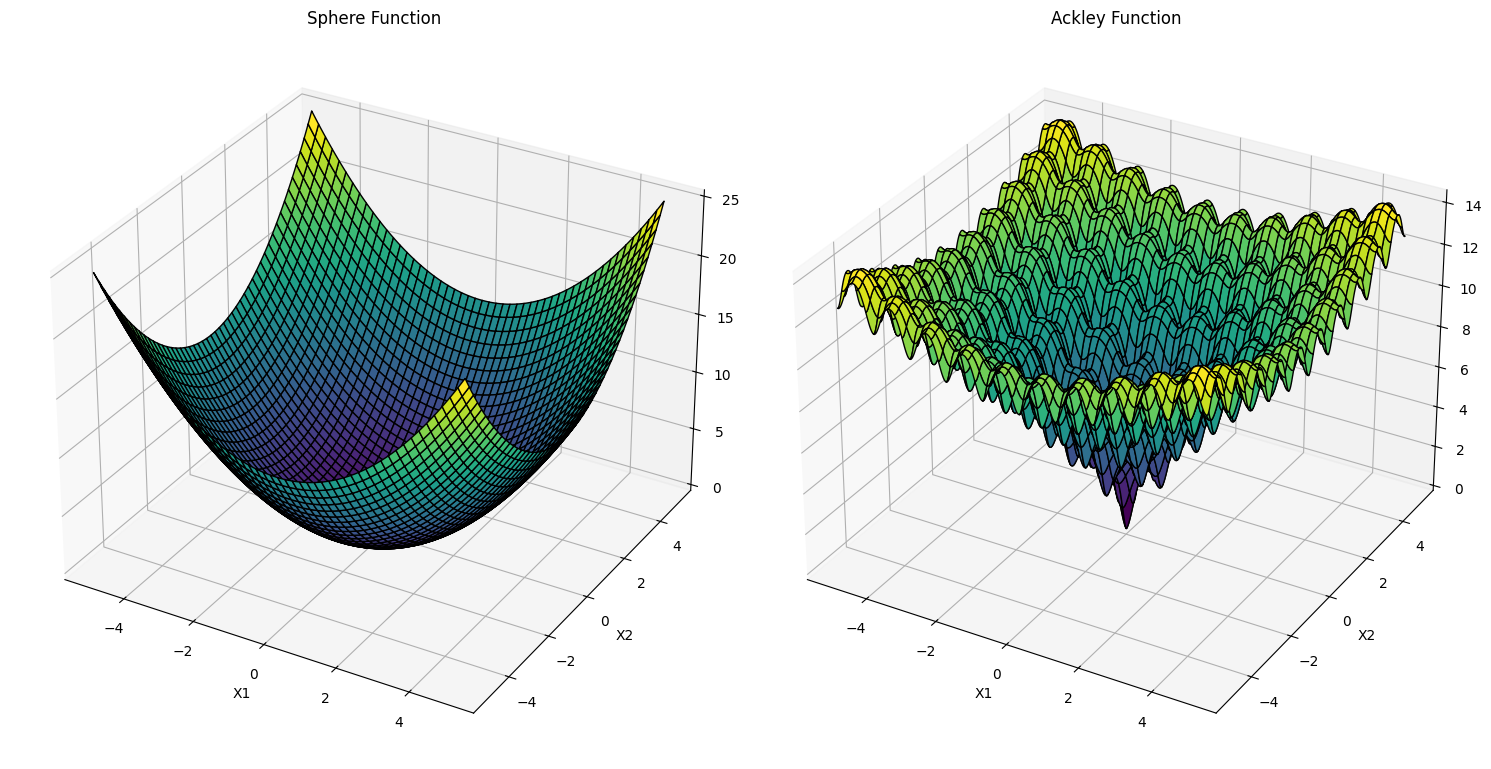

In [7]:
# Create 3D plot
fig = plt.figure(figsize=(15, 8))

titles = ["Sphere Function", "Ackley Function"]
for idx, z in enumerate([z_unimodal, z_multimodal]):
    # Create sub-plot
    ax = fig.add_subplot(121 + idx, projection="3d")

    # Plot the surface
    ax.plot_surface(X, Y, z, cmap="viridis", edgecolor="k")

    # Set labels
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title(titles[idx])
    # ax.autoscale(True)

# Show the plot
plt.tight_layout()
plt.show()

---
**Question 1.1 (0-0.2 pt):** Looking at the Sphere and Ackley functions, please discuss the characteristics of these functions and compare their complexity in terms of local and global optima.

**Answer:** Sphere functions has one local and global optima (these are the same points), while Ackley function features many local optima and only one global optimum. That is, sphere function is convex, and ackley function is non-convex. 

---
**Question 1.2 (0-0.25-0.5 pt):** Please provide a pseudo-code for your evolutionary algorithm. Please try to be as formal as possible!

**Answer:**  
1. **Initialization**: population $X$ with dimensions $(N, D)$  
2. While **LOOP**:  
    **PARENT SELECTION**
    - calculatin the probabilities of being selected:
        since we are aiming minimization, probabilities should be inverted and scaled:
        $$
        \tilde{f}_i = \max(f_i, \varepsilon)
        $$

        $$
        q_i = \frac{1}{1 + \tilde{f}_i}
        $$

        $$
        p_i = \frac{q_i}{\sum_{j=1}^{n} q_j}
        $$  
    - selecting $N$ parents based on the probabilities (with replacement)  

    **CROSSOVER**  
    - copying parents to an array of offsprings
    - with a chance of `p_crossover` changing the `offspring_i`'s genotype to concatenation of $$concatenation(parent_j[:t], parent_k[t:]),$$ where $k$, $j$, and $t$ are arbitrary indices  

    **MUTATION**
    - with a chance of `mutation_rate` adding Guassian noise 
        $
        noise \sim \mathcal{N}(0, 2.5)
        $
    and clipping off if values exceding [-50, 50]  

    **EVALUATION**
    - evaluating fitness of the function using the objective function  

    **SURVIVOR SELECTION**
    - choosing best $N$ individuals among parents and offsprings based on the fitness scores  
3. **OUTPUT:** best `x` representative, best `fitness` score

---
**Task 1.1: Implementation of Evolutionary Algrotihm (0-0.65-1.3-1.95-2.6 pt):** Implement an evolutionary algorithm and its components to find the minimum point of a function. Here, domain should be between [-50,50].

In [8]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 0.65 pts if the code works but some functions are incorrect and it is badly explained
# 1.3 pts if the code works but some functions are incorrect but it is explained well
# 1.95 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 2.6 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################


#Initialize a population randomly based on the population size and dimensions
def initialization(population_size, num_dimensions):
    """
    Initialize the starting population with random individuals.
    Each gene of an individual corresponds to a point on a dimension in the function
    """

    ################################################################

    # PLEASE FILL IN
    # initializing the population uniformly with random values between -50 and 50
    x = np.random.uniform(low=-50, high=50, size=(population_size, num_dimensions))

    ################################################################

    return x #return population


# Implement the evaluation function that can evaluate all the solutions in a given population.
def evaluation(x, objective_function):
    """Evaluate the fitness of the population members"""

    ################################################################

    # PLEASE FILL IN
    # calculating the fitness for each individual 
    fitness = np.array([objective_function(i) for i in x])

    ################################################################
    return fitness


# Implement the crossover operator by choosing a suitable method. For inspiration, take a look at the lecture slides
def crossover(x_parents, p_crossover):
    """Perform crossover to create offsprings."""

    ################################################################

    # PLEASE FILL IN

    # we implement the one-point crossover method
    offspring = x_parents.copy()
    num_parents = len(x_parents)

    for i in range(0, num_parents):
        if np.random.rand() < p_crossover:  # check if crossover should be performed

            # parents and threshold point are randomly selected
            j = np.random.randint(0, num_parents)
            k = np.random.randint(0, num_parents)
            threshold = np.random.randint(0, x_parents.shape[1])

            # combining the genotypes of two parents
            offspring[i] = np.concatenate([x_parents[k, :threshold], x_parents[j, threshold:]])

    ################################################################

    return offspring


# Implement the crossover operator by choosing a suitable method. For inspiration, take a look at the lecture slides
def mutation(x, mutation_rate):
    """Apply mutation to an individual."""

    ################################################################

    # PLEASE FILL IN
    # with a chance of mutation_rate, we add gaussian noise N(0, 2.5) to each gene of the individual
    mutated = x.copy()
    for j in range(len(x)):
        if np.random.rand() < mutation_rate:
            g_noise = np.random.normal(0, 2.5, size=x[j].shape)
            mutated[j] = np.clip(mutated[j] + g_noise, -50, 50)

    ################################################################

    return mutated


def parent_selection(x, f):
    """Select parents for the next generation"""

    ################################################################

    # PLEASE FILL IN
    # in case of too small fitness values, we add a small constant to avoid raising value errors
    eps = 1e-8
    f_shifted = f.copy()
    f_shifted[f_shifted < eps] = eps

    # as we are minimizing the objective function, we invert the fitness values to give higher probabilities to better individuals
    inverted_probabilities = 1.0 / (1.0 + f_shifted)
    probabilities = inverted_probabilities / np.sum(inverted_probabilities)
    
    # sampling parents based on the calculated probabilities
    i = np.random.choice(len(x), size=len(x), p=probabilities)
    x_parents = x[i]
    f_parents = f[i]
    
    ####################################
    return x_parents, f_parents


def survivor_selection(x, f, x_offspring, f_offspring):
    """Select the survivors, for the population of the next generation"""


    ################################################################

    # PLEASE FILL IN
    # simply combining the parents and offspring and selecting the best N individuals based on their fitness values
    x_combined = np.vstack((x, x_offspring))
    f_combined = np.hstack((f, f_offspring))

    indices = np.argsort(f_combined)
    indices = indices[:len(x)]  # we do not change the population size 

    x = x_combined[indices]
    f = f_combined[indices]

    ################################################################

    return x, f


def ea(
    # hyperparameters of the algorithm
    population_size,
    max_fit_evals,  # Maximum number of evaluations
    p_crossover,  # Probability of performing crossover operator
    m_rate,  # mutation rate
    dimensions,  # number of dimensions
    objective_function,  # objective function to be minimized
):
    # Calculate the maximum number of generations
    # Maximum number of function evaluations should be the same independent of the population size
    max_generations = int(max_fit_evals / population_size)  # DO NOT CHANGE



    ################################################################
    # PLEASE FILL IN

    x = initialization(population_size, dimensions)
    f = evaluation(x, objective_function)
    
    ################################################################

    # Find the best individual and append to a list to keep track in each generation
    idx = np.argmin(f)
    x_best = [x[idx]]
    f_best = [f[idx]]

    # Loop over the generations
    for i in range(max_generations - 1):
        # Perform the EA steps


        ################################################################

        # loop is as described in the pseudocode
        x_parents, f_parents = parent_selection(x, f)
        x_offspring = crossover(x_parents, p_crossover)
        x_offspring = mutation(x_offspring, m_rate)
        f_offspring = evaluation(x_offspring, objective_function)
        x, f = survivor_selection(x, f, x_offspring, f_offspring)

        ################################################################


        # Find the best individual in current generation and add to the list
        idx = np.argmin(f)
        xi_best = x[idx]
        fi_best = f[idx]
        if fi_best < f_best[-1]:
            x_best.append(xi_best)
            f_best.append(fi_best)
        else:
            x_best.append(x_best[-1])
            f_best.append(f_best[-1])

    return x_best, f_best  # return the best solution and fitness in each generation

#### Check Your Implementation: Running The Evolutionary Algorithm

Run the cell below, if you implemented everything correctly, you should see
the algorithm running.

In [9]:
# Dummy parameters
kwargs = {
    "population_size": 20,
    "max_fit_evals": 1000,  # maximum number of fitness evaluations
    "p_crossover": 0.9,  # crossover probability
    "m_rate": 0.1,  # mutation rate
    "dimensions": 10,
    "objective_function": Sphere,
}

# Run the EA
x_best, f_best = ea(**kwargs)

# Print the best individual and its fitness
print("Best solution:", x_best[-1])
print("Best Fitness:", f_best[-1])

# Clear cache
del x_best, f_best, kwargs

Best solution: [  2.04646452   5.62173298  -3.13914653   0.69034162 -10.29782173
   9.19385671  -3.12346534  -0.63232142   1.29452374  -4.38700395]
Best Fitness: 26.77723063491938


**Reults and statistical analysis**

Remember that the EAs are sthocastic algorithms that can produce different results as a result of independent runs.

How do we find overal performance of the algorithm and compare the results?

By running multiple times and performing statitical tests. Therefore, you would need to run your algorithm **20 times** and plot the *average* results.

First, we would need to **defining some helper functions** for finding the average and standard deviations of multiple runs and ploting them. In the next few cells, we give you some pre-made functions for this purpose.

There is no work for you to do, but do look over them and get familiar with how they operate.

In [10]:
def calculate_mean_std(f_best):
    """This is a helper function to calculate the mean and standard deviation of the best fitness values."""
    f_best = np.array(f_best)
    avg = np.mean(f_best, axis=0)
    std = np.std(f_best, axis=0)
    return avg, std

In [11]:
def run_experiment(population_size, p_crossover, m_rate):
    runs = 20  # DO NOT CHANGE - number of runs
    max_fit_evals = 5000  # DO NOT CHANGE

    sphere10D = []
    sphere50D = []
    ackley10D = []
    ackley15D = []

    for _ in range(runs):
        _, f_best_sphere10D = ea(
            population_size[0],
            max_fit_evals,
            p_crossover[0],
            m_rate[0],
            10,
            Sphere,
        )
        _, f_best_sphere50D = ea(
            population_size[1],
            max_fit_evals,
            p_crossover[1],
            m_rate[1],
            50,
            Sphere,
        )
        _, f_best_ackley10D = ea(
            population_size[2],
            max_fit_evals,
            p_crossover[2],
            m_rate[2],
            10,
            Ackley,
        )
        _, f_best_ackley15D = ea(
            population_size[3],
            max_fit_evals,
            p_crossover[3],
            m_rate[3],
            15,
            Ackley,
        )

        sphere10D.append(f_best_sphere10D)
        sphere50D.append(f_best_sphere50D)
        ackley10D.append(f_best_ackley10D)
        ackley15D.append(f_best_ackley15D)

    # find average and std of the runs
    sphere10D_avg, sphere10D_std = calculate_mean_std(sphere10D)
    sphere50D_avg, sphere50D_std = calculate_mean_std(sphere50D)
    ackley10D_avg, ackley10D_std = calculate_mean_std(ackley10D)
    ackley15D_avg, ackley15D_std = calculate_mean_std(ackley15D)

    avgs = [sphere10D_avg, sphere50D_avg, ackley10D_avg, ackley15D_avg]
    stds = [sphere10D_std, sphere50D_std, ackley10D_std, ackley15D_std]
    all_runs = [
        sphere10D,
        sphere50D,
        ackley10D,
        ackley15D,
    ]

    return avgs, stds, all_runs

In [12]:
def generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2,
    stds_experiment_2,
    n_columns,
    n_queens,
):
    """This helper function generates subplots for the experiments."""
    fig, axes = plt.subplots(nrows=1, ncols=n_columns, figsize=(18, 6))

    for i in range(len(avgs_experiment_1)):
        if avgs_experiment_2 is not None:
            # Plot data for subplot 1
            axes[i].plot(avgs_experiment_2[i], label="Experiment 2", color="green")
            axes[i].fill_between(
                np.arange(len(avgs_experiment_2[i])),
                avgs_experiment_2[i] - stds_experiment_2[i],
                avgs_experiment_2[i] + stds_experiment_2[i],
                alpha=0.2,
                color="green",
            )
            axes[i].set_ylim(bottom=0)

            if n_queens:
                axes[i].set_ylim(top=n_queens[i])

        axes[i].plot(avgs_experiment_1[i], label="Experiment 1", color="blue")
        axes[i].fill_between(
            np.arange(len(avgs_experiment_1[i])),
            avgs_experiment_1[i] - stds_experiment_1[i],
            avgs_experiment_1[i] + stds_experiment_1[i],
            alpha=0.2,
            color="blue",
        )
        axes[i].set_title(labels[i])
        axes[i].set_ylim(bottom=0)
        if n_queens:
            axes[i].set_ylim(top=n_queens[i])

    # Set common labels and title
    for ax in axes:
        ax.set_xlabel("Generations")
        ax.set_ylabel("Average Best Fitness")
        ax.legend()

    plt.tight_layout()

#### Running The Experiments

In the following cell we run the EA over several different hyper-parameter values.

In [13]:
np.random.seed(371)

population_size = [50, 50, 50, 50]  # DO NOT CHANGE
p_crossover = [0.8, 0.8, 0.8, 0.8]  # DO NOT CHANGE
m_rate = [0.1, 0.1, 0.1, 0.1]  # DO NOT CHANGE

avgs_experiment_1, stds_experiment_1, all_runs_experiment_1 = run_experiment(
    population_size, p_crossover, m_rate
)

#### Plotting The Results

In the following cell we plot the results of the experiments.

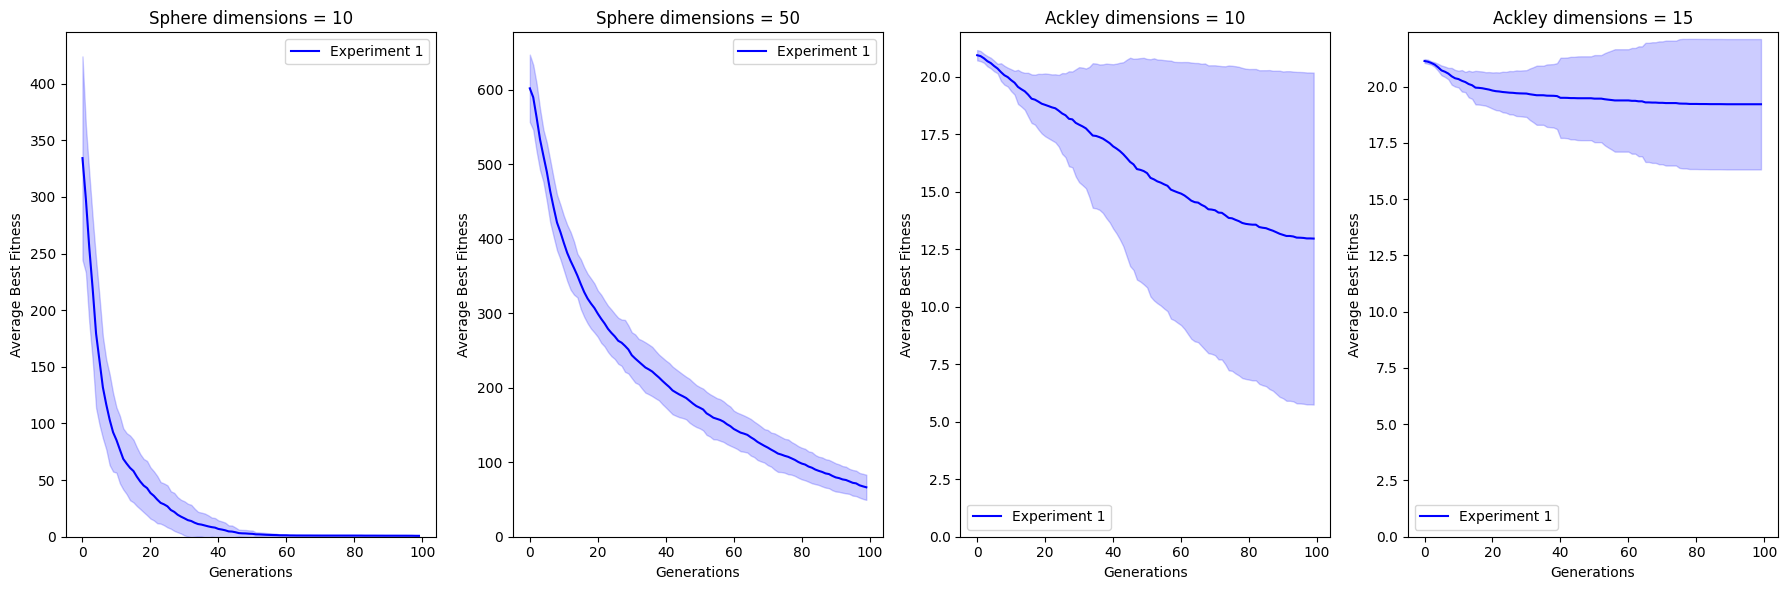

In [14]:
labels = [  # DO NOT CHANGE
    "Sphere dimensions = 10",
    "Sphere dimensions = 50",
    "Ackley dimensions = 10",
    "Ackley dimensions = 15",
]

generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2=None,
    stds_experiment_2=None,
    n_columns=4,
    n_queens=None,
)

---

**Question 1.3 (0-0.25-0.5 pt):** Describe the results that you see in the line graphs. How is the performance of the EA on Sphere and Ackley functions? How the results are different between functions and dimensions? What causes these differences?

**Answer:**  
- The performance pf the EA on both functions is less impressive than it might be if the gradient-descent based method were used (to my mind). In any conditions the global optimum has been never reached and the searching algorithm decayed quickly.   
- The EA performs better on the Sphere function, irrespective of the dimensionality. That might be explained by the features of the functions: as we stated above, Ackley function is non-convex that's why the EA may stuck in some local minima and never escape while Sphere is smooth.  
- At the same time, the fewer dimensions are in the function, the better overall performance of the EA is. No surprise that it is so: the more dimensions are in the function > the more permutations and improvements should be made for every given point >> less probability of reaching the optimum > worse performance

---
**Improve Your Results**

Experiment with the hyperparameters of the algorithm and find a set of parameters that can perform better than the previous results. Compare the results using statistical test and find a settings where there is a statistically significant improvement.

You can adjust the *population size*, *crossover probability* and *mutation rate* to find the settings that can work statistically better relative to the previous results. Please look at the "ADJUST THESE VALUES" part to experiment and improve your solutions.

Optionally, you can also improve your algorithm by implementing/changing strategies used

**My explanation of the improvements made**  

**0. What might be the problem with the previous solution**

I believe that the solution I've implemented has a certain problem: from around the 40th iteration it is starting to plateau, irrespectively of the functions' features. So, one of the ways how to improve it is to set up new hyperparameters in such a way that we force more exploration on whichever iteration. That is, we have to increase the probability of crossover and mutation.  

Moreover, we can adjust some functions of our EA. 

**1. Parent selection**

The current implementation of parent selection exploits the probabilities of the best individuals. It basically means that over iterations we would unintentionally stuck with alike genotypes. That's why the new one selects just random individuals with no regard for their fitness score.

**2. Crossover**  

(I tried to come up with some other implementations of mutation, survivor selection, and crossover including enlarging number of offsprings but nothing has given any truly significant difference. So I looked for theory on this topic and find out [the blending crossover technique](https://hexdocs.pm/genex/operators-crossover.html#blend)). So, I will try to explain the idea behind this method.  
This approach lets us creating new genotypes which are not a simple combinations of the parents' genes. Rather than that, blending produces an offspring whose every gene value lies between the corresponding genes of its parents. However, a beta parameter is also being established for every gene: it is responsible for how close the offspring's gene to parent 1 or parent 2. As you may see, this method is very promising in the sense that it can solve the problem of getting stuck in local minima.    
But the formula to be found on [wikipedia page dedicated to the intermediate recombination](https://en.wikipedia.org/wiki/Crossover_(evolutionary_algorithm)#Intermediate_recombination) (pretty the same blending crossover). Here it goes:  
$$
\alpha_{new} \ = \beta * {parent_i} \ + (1 - \beta) * {parent_j} \,
$$
where $\beta$ has the dimension of a ${parent_t}$ $-$ $(1, D)$

In [15]:
# Grading (bonus points):
# 0.4 pts bonus for the optional improvement: if you implement different strategy, it works and produces significantly better results
# Different strategy could be a different implementation of the mutation/crossover/parent or survival selection mechanisms


# Implement your strategy here and integrate with the Evolutionary Algorithm
# PLEASE FILL IN

def parent_selection(x, f):
    """Select parents for the next generation"""

    ################################################################

    # PLEASE FILL IN

    # just randomly shuffling the population and selecting parents without any bias towards better individuals
    indices = np.random.choice(x.shape[0], size=x.shape[0])
    x_parents = x[indices]
    f_parents = f[indices]

    ####################################
    return x_parents, f_parents


def crossover(x_parents, p_crossover):
    """Perform crossover to create offsprings."""

    ################################################################

    # PLEASE FILL IN
    num_parents, dimensions = x_parents.shape
    offspring = x_parents.copy()
    for i in range(num_parents):
        # the algorithm is described in the markdown cell above
        # https://hexdocs.pm/genex/operators-crossover.html#blend
        if np.random.rand() < p_crossover:
            j = np.random.choice(num_parents)
            beta = np.random.rand(dimensions)
            offspring[i] = beta * x_parents[i] + (1 - beta) * x_parents[j]

    ################################################################

    return offspring

##################

In [16]:
################################################################

population_size = [  # if we change the population size, 
                     # we should adjust the max_fit_evals to keep the number of generations the same across different population sizes
                     # but for the sake of the experiment, we keep the population size the same across all runs to have a fair comparison
    50,
    50,
    50,
    50,
]


p_crossover = [  # we increase the crossover probability to enhance the exploration of the search space
    0.8,
    0.9,
    0.95,
    1.0,
]
m_rate = [  # same here
    0.1,
    0.2,
    0.25,
    0.35,
]

# i don't get it: why do we need to raise the error here?

# raise NotImplementedError
# Remove the line above once you've made the changes you want

################################################################

**Running the experiment again**

In [17]:
np.random.seed(43)
avgs_experiment_2, stds_experiment_2, all_runs_experiment_2 = run_experiment(
    population_size, p_crossover, m_rate
)

**Plotting the new and previous results**

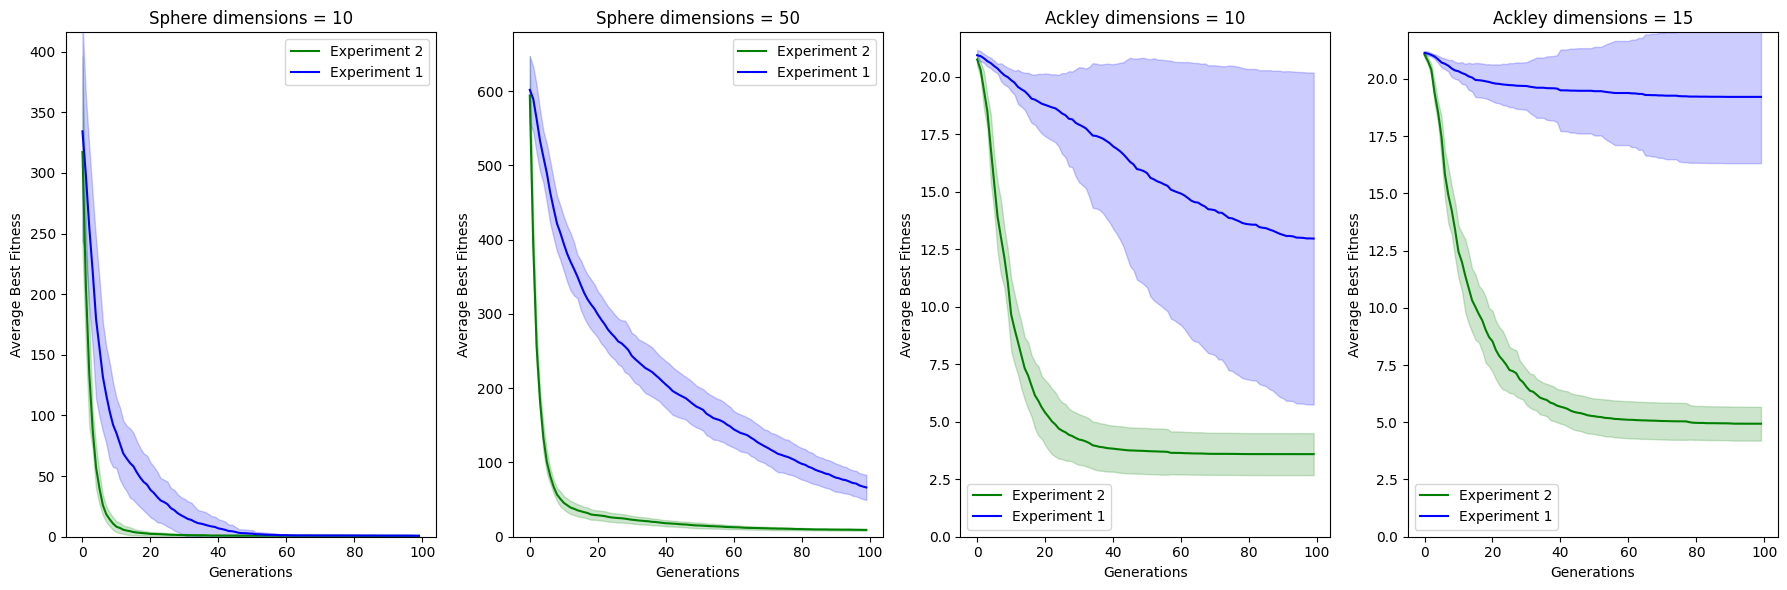

In [18]:
labels = [
    "Sphere dimensions = 10",
    "Sphere dimensions = 50",
    "Ackley dimensions = 10",
    "Ackley dimensions = 15",
]  # DO NOT CHANGE

generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2=avgs_experiment_2,
    stds_experiment_2=stds_experiment_2,
    n_columns=4,
    n_queens=None,
)

**Measuring the statistical significance of differences of two sets of experiment results**

The final step is to calculate whether the results from your set of hyperparameters (experiment 2) resulted in significantly better results.

To do this, we will perform a statistical test know as [rank-sum test](https://www.wikiwand.com/en/Mann%E2%80%93Whitney_U_test).

You will calculate the rank-sum for the results of the first and second experiments.

In [19]:
alpha = 0.05

# this loops over the 4 different functions we have
#   (Sphere dimensions = 10, Sphere dimensions =50, Ackley dimensions = 10, Ackley dimensions = 15)
labels = [
    "Sphere function 10 dimensions:",
    "Sphere function 50 dimensions:",
    "Ackley function 10 dimensions:",
    "Ackley function 15 dimensions:",
]
for i in range(4):
    runs_exp_1 = all_runs_experiment_1[i]
    runs_exp_2 = all_runs_experiment_2[i]

    best_per_run_exp_1 = [sublist[-1] for sublist in runs_exp_1]
    best_per_run_exp_2 = [sublist[-1] for sublist in runs_exp_2]

    t_statistic, p_value = ranksums(best_per_run_exp_1, best_per_run_exp_2)
    if p_value < alpha:
        # if np.mean(best_per_run_exp_1) < np.mean(best_per_run_exp_2):
        print(
            labels[i],
            "Experiment 1 average:",
            np.mean(best_per_run_exp_1),
            ", Experiment 2 average:",
            np.mean(best_per_run_exp_2),
            ",significant difference.",
        )
        # else:
        #    print(labels[i], "significant difference. Experiment 2 is better.")
    else:
        # if np.mean(best_per_run_exp_1) < np.mean(best_per_run_exp_2):
        print(
            labels[i],
            "Experiment 1 average:",
            np.mean(best_per_run_exp_1),
            ", Experiment 2 average:",
            np.mean(best_per_run_exp_2),
            ",no significant difference.",
        )
        # else:
        #    print(labels[i], "no significant difference. Experiment 2 is better.")

Sphere function 10 dimensions: Experiment 1 average: 0.7897329596194236 , Experiment 2 average: 0.7235779590467502 ,no significant difference.
Sphere function 50 dimensions: Experiment 1 average: 66.33315809767105 , Experiment 2 average: 9.174439526212117 ,significant difference.
Ackley function 10 dimensions: Experiment 1 average: 12.959422682831203 , Experiment 2 average: 3.590017346118453 ,significant difference.
Ackley function 15 dimensions: Experiment 1 average: 19.212553825931813 , Experiment 2 average: 4.936663974119588 ,significant difference.


---
**Question 1.4 (0-0.3-0.6-0.9-1.2 pt):** Please improve the results significantly in each case (i.e. on Sphere and Ackley functions with 10, 50 and 10, 15 dimensions respectively) and discuss what kinds of changes you had to do to achieve this improvement. Please provide your reasoning why the new parameter settings worked better.

Grading:

0 pts: No answer or non of the cases were improved.

0.3 pts: At least one of the cases improved significantly but reasons why were not clearly explained.

0.6 pts: One or two cases improved significantly and the reasons why were somewhat clear.

0.9 pts: Three to four cases improved significanlty and the reasons why are clear.

1.2 pts: All of the cases improved significanlty and the reasons why are clear.


**Answer:**  

The description of the changes made could be found in one of the cells above ("My explanation of the improvements made"). That's why here I'm going to descibe the results mainly.  
One can easily notice that the results have improved drastically. The approach of using the blending technique has led to the faster descent to the optimum across all four functions. Throughout first 10 iterations within Sphere function and 40 iterations within Ackley function, a significant descent takes place. This means that, at least at the begining, our EA handles local optima and escapes them by creating new points using blending method. However, searching algorithm nevertheless stops at some point and stays on the plateau. That might be explained by the effect of the survival selection where an eletist approach is applied. This means that up to the n-th iteration survival selection leaves the points similar to each other and even blending does not help. Moreover, blending does also blur distinctions between the points because it creates the points that stay within the same domain that two parents had. That's why by the 10 or 40 iterations we lose all the exploration we could have.

---
## Part 2: Discrete Optimization (The N-Queens Problem, 5 points total)

Implement an Evolutionary Algorithm for the **n-queens problem**.
Below is a visualization of a solution for the n-queens problem when n = 4. Observe that none of the queens are attacking each other.

We would like to implement an EA that can find a solution for any given N by N board but in this case it is required to place N queens where none of them attack each other.

You may use the implementation of the EA you used for solving continuous problems in Part 1. But remember, this is a discere problem so you would need to think about how to represent the solutions and search using the evolutionary operators.

Consider, what changes you would need to do!


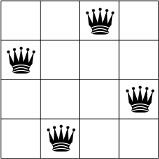


It is usually better to start simple and generalize your implementation. So, let's start with the case when **N = 4**.

**Question 2.1 (0-0.3 pt):** How do you represent a solution (a 4 queen placement on a 4x4 chess board)? In particular, specify the length of your genotype representation, what each gene (dimension) represents, and what values they can get.

**Answer:**
- Dimension: an array of the length $n$ consisting of the integers $\in$ $[0, n-1]$.
- Each gene (value) represents the row on which a queen stands, each position of the gene represents the column number

**Question 2.2 (0-0.2 pt)**: Please write down an example representation and discuss what it means.

**Answer:**  
- Consider the following array: [2, 0, 3, 1]. It means that queens stay at coordinates (0, 2), (1, 0), (2, 3), and (3, 1).  
- (For the sake of preserving the convenience of dealing with indices, we start counting rows and columns from 0 and end on (n-1).)

**Question 2.3 (0-0.2 pt):** How many possible solutions can be generated in your representation?

**Answer:**
- There is a constraint: apparently, no two queens can stand on the same row (otherwise, they would beat each other).
- That's why there exists $n!$ different solutions.

---
**Task 2.1 (0-0.20-0.40-0.80):** Implementation of solution encoding, visualization and evaluation functions.

In [4]:
################################################################


example_solution = np.array([2, 0, 3, 1])

################################################################

Write a function below that can visualize your solution. For instance, the output may look like below, a matrix representing the 4x4 chess board where each Q indicates a queen placement and dots are empty cells.


![image.png](attachment:ef1059d6-48a4-4e38-b902-323f3d61a745.png)

In [7]:
def visualize_solution(solution):
    """Visualize the placement of queens on the chessboard."""

    ################################################################
    n = len(solution)
    for i in range(n):
        for j in range(n):
            if solution[i] == j:
                print('Q', end=' ')
            else:
                print('.', end=' ')
        print()
    print()

    ################################################################

Write the evaluation function to assess how good your solution is.

In [5]:
def evaluate_solution_n_queens(solution):
    """Calculate the fitness of a solution."""
    ################################################################

    # PLEASE FILL IN

    # we want to maximize fitness, which is the number of non-attacking pairs of queens
    n = len(solution)
    attacks = 0
    for i in range(n):
        for j in range(i + 1, n):
            # two queens attack each other if they are in the same row or in the same diagonal
            # first condition checks same row, second checks same diagonal
            if solution[i] == solution[j] or abs(solution[i] - solution[j]) == abs(i - j):
                attacks += 1

    # in range (0, 1]
    fitness = 1 / (1 + attacks)

    ################################################################

    return fitness

Try your implementations to see if your solution encoding matches to visualization and whether the fitness is computed correctly.

In [8]:
#################################
# Grading
# 0 pts: No attempt, representation discussed does not match with the implementation and visualization, fitness is not correct.
# 0.20 : Solution representation matches with visualization, fitness computation is not correct, no explanation in the code.
# 0.50 : Solution representation matches with visualization, fitness computation is correct, no explanation in the code.
# 0.80 : Solution representation matches with visualization, fitness computation is correct, the implementation explained well.
################################################################


###################### DO NOT CHANGE #########################
print("Genotype (solution representation):", example_solution)
print("Phenotype (solution visualization):")
visualize_solution(example_solution)
print("Solution fitness", evaluate_solution_n_queens(example_solution))
###################### DO NOT CHANGE #########################

Genotype (solution representation): [2 0 3 1]
Phenotype (solution visualization):
. . Q . 
Q . . . 
. . . Q 
. Q . . 

Solution fitness 1.0


---

**Task 2.2 (0-0.4-0.8-1.2-1.6 pt):** Write an evolutionary algorithm that can initialize a population of solutions and finds N queen placement to NxN board optimizing the number of attacks (could be minimization or maximization based on your evaluation function of the solutions).

In [9]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 0.4 pts if the code works but some functions are incorrect and it is badly explained
# 0.8 pts if the code works but some functions are incorrect but it is explained well
# 1.2 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 1.6 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################


#initialize a population of solutions for the N queens problem where num_dims = N
def initialization_n_queens(population_size, num_of_dims):
    """Generate a population of solutions."""
    ################################################################

    # PLEASE FILL IN

    # here we create a population of random permutations from 0 to n-1
    x = np.array([np.random.permutation(num_of_dims) for i in range(population_size)])
    ################################################################

    return x #return population


def evaluation_n_queens(x):
    """Evaluate the whole population and return the fitness of each."""
    return np.array([evaluate_solution_n_queens(solution) for solution in x])


def crossover_n_queens(x_parents, p_crossover):
    """Perform crossover to create offsprings."""

    ################################################################

    # PLEASE FILL IN
    
    # we implement the one random point crossover method
    offspring = x_parents.copy()
    num_parents = len(x_parents)

    for i in range(0, num_parents):
        if np.random.rand() < p_crossover:  # check if crossover should be performed

            # parents and threshold point are randomly selected
            j = np.random.randint(0, num_parents)
            k = np.random.randint(0, num_parents)
            threshold = np.random.randint(0, x_parents.shape[1])

            # combining the genotypes of two parents
            offspring[i] = np.concatenate([x_parents[k, :threshold], x_parents[j, threshold:]])

            # we need to fix the offspring to make sure it is a valid solution (let op the validation function below)
            offspring[i] = validation(offspring[i], x_parents)

    ################################################################

    return offspring


def validation(one_offspring, x_parents):
    '''If an offspring is not a valid solution, fix it'''

    # the idea here is to count duplicates and missing values
    unique, counts = np.unique(one_offspring, return_counts=True)
    duplicates = unique[counts > 1]
    n = x_parents.shape[1]
    missing = set(range(n)) - set(unique)

    # if there are duplicates
    if len(duplicates) > 0:

        # for every duplicate, we replace it with a missing value
        for dup in duplicates:
            if len(missing) > 0:
                missing_val = missing.pop()  # we take one missing value and remove it from the set
                idx = np.where(one_offspring == dup)[0][0]  # we take index of first occurenceof  the duplicate
                one_offspring[idx] = missing_val

    return one_offspring


def mutation_n_queens(x, mutation_rate):
    """Apply mutation to an individual."""

    ################################################################

    # PLEASE FILL IN
    x = x.copy()
    n = x.shape[1]
    for i in range(x.shape[0]):
        if np.random.rand() < mutation_rate:
            # choosing two random and swap! 
            swap1, swap2 = np.random.choice(n, size=2, replace=False)
            x[i, swap1], x[i, swap2] = x[i, swap2], x[i, swap1]


    ################################################################

    return x


def parent_selection_n_queens(x, f):
    """Select parents for the next generation"""

    ################################################################

    # PLEASE FILL IN
    # just randomly shuffling the population and selecting parents without any bias towards better individuals
    # indices = np.random.choice(x.shape[0], size=x.shape[0])
    # x_parents = x[indices]
    # f_parents = f[indices]

    probabilities = f / np.sum(f)  # maximizeing fitness means giving higher probabilities to better individuals
    n = len(x)
    indices = np.random.choice(n, size=n, p=probabilities)
    x_parents = x[indices]
    f_parents = f[indices]

    ####################################
    return x_parents, f_parents


def survivor_selection_n_queens(x, f, x_offspring, f_offspring):
    """Select the survivors, for the population of the next generation"""


    ################################################################

    #  PLEASE FILL IN
    # same code as in the first part
    # simply combining the parents and offspring and selecting the best n individuals based on their fitness values
    x_combined = np.vstack((x, x_offspring))
    f_combined = np.hstack((f, f_offspring))

    indices = np.argsort(f_combined)
    indices = indices[-len(x):]  # we do not change the population size and we want to maximize the fitness, so we take the last n indices

    x = x_combined[indices]
    f = f_combined[indices]

    ################################################################

    return x, f


def ea_n_queens(population_size, max_fit_evals, p_crossover, m_rate, num_of_dims):
    # Calculate the maximum number of generations
    max_generations = int(max_fit_evals / population_size)

    #########################
    #  PLEASE FILL IN
    x = initialization_n_queens(population_size, num_of_dims)
    f = evaluation_n_queens(x)

    #########################

    # Get best individual and append to list
    idx = np.argmax(f)
    x0_best = x[idx]
    f0_best = f[idx]
    x_best = [x0_best]
    f_best = [f0_best]

    # Loop over the generations
    for _ in range(max_generations - 1):
        # Select population size parents

        #########################
        # pretty the same as in the first part
        x_parents, f_parents = parent_selection_n_queens(x, f)
        x_offspring = crossover_n_queens(x_parents, p_crossover)
        x_offspring = mutation_n_queens(x_offspring, m_rate)
        f_offspring = evaluation_n_queens(x_offspring)
        x, f = survivor_selection_n_queens(x, f, x_offspring, f_offspring)

        #########################

        # Find the best individual in current generation and add to the list
        idx = np.argmax(f)
        xi_best = x[idx]
        fi_best = f[idx]
        if fi_best > f_best[-1]:
            x_best.append(xi_best)
            f_best.append(fi_best)
        else:
            x_best.append(x_best[-1])
            f_best.append(f_best[-1])

        # Append the best individual to the list
        f_best.append(fi_best)
        x_best.append(xi_best)
    return x_best, f_best

---
**Results:**

Run the code below to run an EA for N=8, 16 and 32, and visualize the best solutions found.


In [11]:
np.random.seed(48)

print("Case when N=8:")

x_best, f_best = ea_n_queens(100, 10000, 0.5, 0.1, 8)


print("Best fitness:", f_best[-1])
print("Best solution found:")
visualize_solution(x_best[-1])

Case when N=8:
Best fitness: 1.0
Best solution found:
. . . Q . . . . 
Q . . . . . . . 
. . . . Q . . . 
. . . . . . . Q 
. . . . . Q . . 
. . Q . . . . . 
. . . . . . Q . 
. Q . . . . . . 



In [12]:
np.random.seed(48)

print("Case when N=16:")
x_best, f_best = ea_n_queens(200, 100000, 0.9, 0.2, 16)


print("Best fitness:", f_best[-1])
print("Best solution found:")
visualize_solution(x_best[-1])

Case when N=16:
Best fitness: 1.0
Best solution found:
. . . . . . . . . . Q . . . . . 
Q . . . . . . . . . . . . . . . 
. . . . . . . . . . . . . Q . . 
. . . . . . Q . . . . . . . . . 
. . . . . . . . . . . . Q . . . 
. . . . . . . Q . . . . . . . . 
. Q . . . . . . . . . . . . . . 
. . . . Q . . . . . . . . . . . 
. . . . . . . . . . . . . . Q . 
. . . . . . . . . Q . . . . . . 
. . . . . . . . . . . . . . . Q 
. . . Q . . . . . . . . . . . . 
. . . . . . . . Q . . . . . . . 
. . . . . . . . . . . Q . . . . 
. . . . . Q . . . . . . . . . . 
. . Q . . . . . . . . . . . . . 



In [13]:
np.random.seed(48)

print("Case when N=32:")
x_best, f_best = ea_n_queens(100, 10000, 0.5, 0.1, 32)

print("Best fitness:", f_best[-1])
print("Best solution found:")
visualize_solution(x_best[-1])

Case when N=32:
Best fitness: 1.0
Best solution found:
. . . . . . . . . . . . . . . . Q . . . . . . . . . . . . . . . 
. . . . . . Q . . . . . . . . . . . . . . . . . . . . . . . . . 
. . . Q . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
. . . . . . . . . . . . . . . . . . . . . . . Q . . . . . . . . 
. . . . . . . . . . . . . . . Q . . . . . . . . . . . . . . . . 
. . . . . . . . . . . . . . . . . . Q . . . . . . . . . . . . . 
. . . . . . . . . . . . Q . . . . . . . . . . . . . . . . . . . 
. . . . . . . . . . . . . . . . . Q . . . . . . . . . . . . . . 
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . Q . . 
. . . . Q . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Q . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . Q . 
. . . . . . . . . . . . . . . . . . . . . . . . Q . . . . . . . 
. . . . . . . . . . . . . . . . . . . . . Q . . . . . . . . . . 
. . . . . . . . Q . . . . . . . . .

---

**Question 2.4 (0-0.2-0.4-0.6-1-1.5 pt):** Describe the results. What was the fitness found for each case? Were you able to find fitness scores of 8, 16 and 32 for N=8, 16 and 32 cases? How did you find them? Did you try improving the results by testing different parameters and/or evolutionary operators?

Grading:

0 pts: no solution or visualization provided.

0.2 pts: Solutions and visualizations were provided, no insights provided how the results achieved.

0.4 pts: Solutions and visualizations were provided, at least for N=8, a optimum solution was found, limited/no insights provided on how this result is achieved.

0.6 pts: Solutions and visualizations were provided, at least for N=8, a optimum solution was found, insights on how this result is achieved provided.

1 pts: Solutions and visualizations were provided, for N=8 and N=16, optimum solutions were found, insights on how this result is achieved provided.

1.5 pts: Solutions and visualizations were provided, for N=8, N=16 and N=32, optimum solutions were found, insights on how this result is achieved provided.

**Answer:**  

The solution was achieved because of the evolionary algorithm that we introduced above. Clearly, the strong points of it are that on each step affecting a genotype, i.e. crossover or mutation, only feasible individuals come out. That is achieved by introducing a new function called `validation` which removes duplicates and inserts missing values into a genotype after a crossover operation. Moreover, after each iteration, our EA selects best individuals based on their fitness score. All in all, this algorithm turns out to be fairly good.

---

#### Plotting the average performance of the algorithm
Use the cells below to plot the results of your algorithm similar to Part 1. The plots should show average and std of 10 runs of EA for n-queens problem for N=8, 16, 32.

In [14]:
def run_experiment_n_queens(population_size, p_crossover, m_rate):
    # These are the hyperparameters of your evolutionary algorithm. You are not allowed to change them.

    max_fit_evals = 10000

    fitness_8 = []
    fitness_16 = []
    fitness_32 = []

    runs = 10

    for run in range(runs):
        print("Run: ", run)

        _, f_best_8 = ea_n_queens(
            population_size[0], max_fit_evals, p_crossover[0], m_rate[0], num_of_dims=8
        )
        _, f_best_16 = ea_n_queens(
            population_size[1], max_fit_evals, p_crossover[1], m_rate[1], num_of_dims=16
        )
        _, f_best_32 = ea_n_queens(
            population_size[2], max_fit_evals, p_crossover[2], m_rate[2], num_of_dims=32
        )
        fitness_8.append(f_best_8)
        fitness_16.append(f_best_16)
        fitness_32.append(f_best_32)

    avg_8, std_8 = calculate_mean_std(fitness_8)
    avg_16, std_16 = calculate_mean_std(fitness_16)
    avg_32, std_32 = calculate_mean_std(fitness_32)

    avgs = [avg_8, avg_16, avg_32]
    stds = [std_8, std_16, std_32]
    all_runs = [fitness_8, fitness_16, fitness_32]

    return avgs, stds, all_runs

In [15]:
np.random.seed(1)
population_size = [100, 100, 100]  # not allowed to change
p_crossover = [0.8, 0.8, 0.8]  # not allowed to change
m_rate = [0.1, 0.1, 0.1]  # not allowed to change

avgs_experiment_1, stds_experiment_1, all_runs_experiment_1 = run_experiment_n_queens(
    population_size, p_crossover, m_rate
)

Run:  0
Run:  1
Run:  2
Run:  3
Run:  4
Run:  5
Run:  6
Run:  7
Run:  8
Run:  9


NameError: name 'calculate_mean_std' is not defined

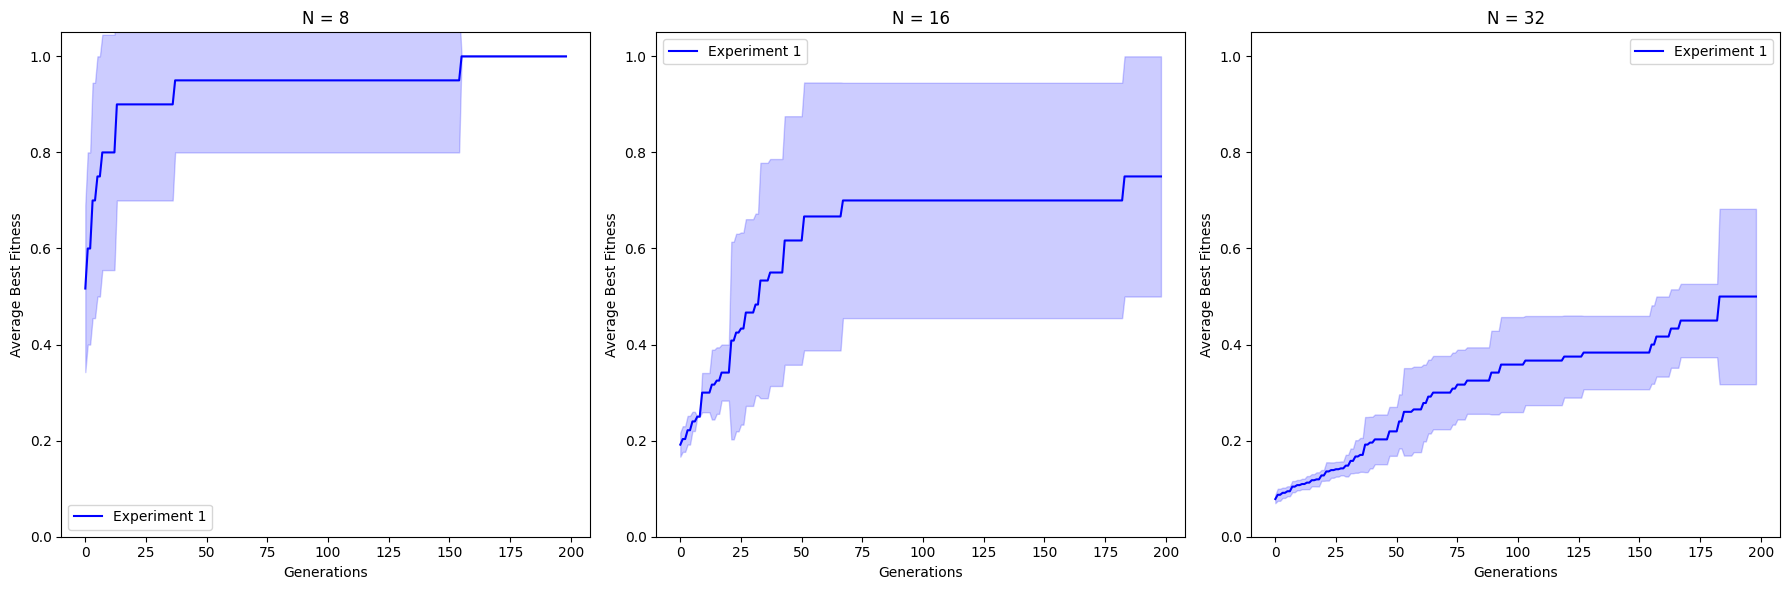

In [ ]:
labels = ["N = 8", "N = 16", "N = 32"]

generate_subplot_function(
    avgs_experiment_1,
    stds_experiment_1,
    labels,
    avgs_experiment_2=None,
    stds_experiment_2=None,
    n_columns=3,
    n_queens=[1.05, 1.05, 1.05],
)

In [31]:
print('average fitness values:')
print('n=8:', avgs_experiment_1[0][-1])
print('n=16:', avgs_experiment_1[1][-1])
print('n=32:', avgs_experiment_1[2][-1])

average fitness values:
n=8: 1.0
n=16: 0.75
n=32: 0.4999999999999999


**Question 2.5 (0-0.2-0.4 pt)** Describe the average performance of the algorithm. What was the maximum average fitness found for each case? Do you see any differences between the problem cases?

**Answer**:  

Please note that I've adjusted the plotting function a bit in such a way that now it's suitable for plotting the fitness scores that I've been calculating in this assignment. (You might have noticed that my fitness score is $1 / (1 + attacks)$ and not the number of non-attacking queens. Thus, the plots should interpreted respectively: `0.5` value means that there is 31/32 non-attacking queens on the board.)  

The average performance depends highly on the number of queens and iterations (generations): the more queens should be placed on the board, the more complex the task becomes; with larger number of iterations, the better results are.  
The maximum average fitness for: 
- n=8 is 1.0 >> perfect, 0 attacks
- n=16 is 0.6 >> ~0.67 attacks avg
- n=32 is 0.55 >> ~0.82 attacks avg

It means that with a larger n, the worse results are. It's all due to the exponential growth $n!$ of possible solutions, so maybe it's better to make one more fitness function here or increase the population size.  

Yes, I can see a difference between n=16 and n=32 cases: it seems that having n=16, at some point we go on the plateau while having n=32, fitness increases almost persistently. That's a bit strange but I guess this is also due to number of dimensions: with n=16 we just stop exploring anything besides our solutions that became to look very alike (maybe a higher mutation rate could improve the situation).